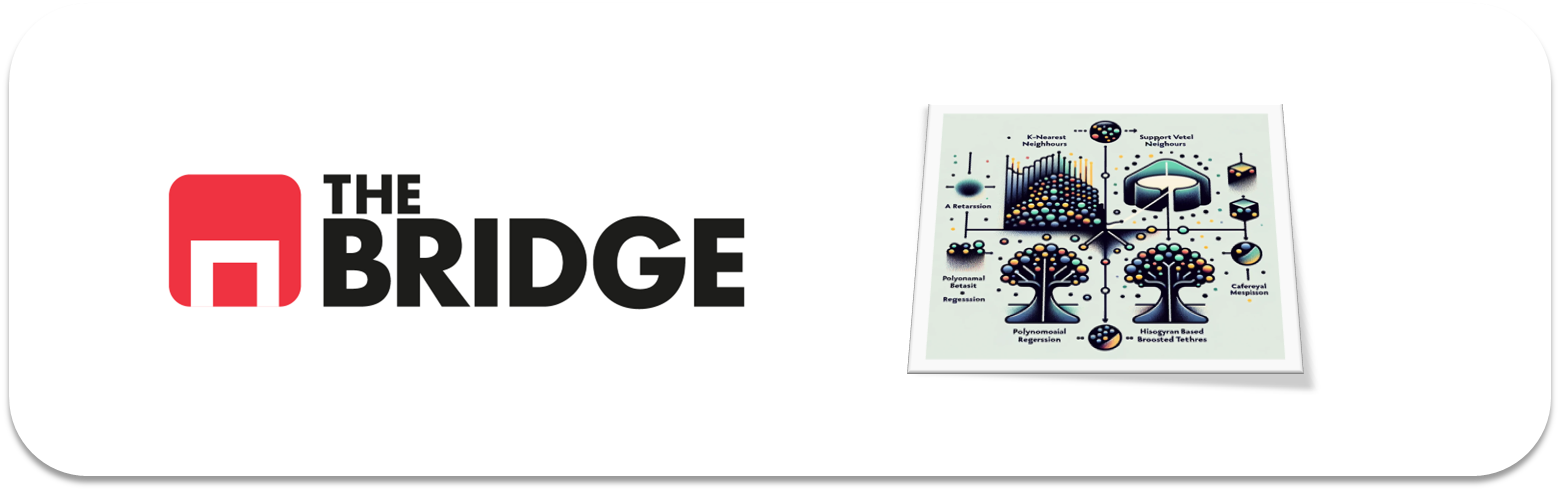

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# =========================================
# PREPROCESADO
# =========================================

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV

# =========================================
# MÉTRICAS
# =========================================

from sklearn.metrics import (
    recall_score,
    classification_report,
    confusion_matrix
)

# =========================================
# MODELOS DE CLASIFICACIÓN
# =========================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

In [2]:
df = pd.read_csv("./data/wines_dataset.csv", sep="|")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red


In [3]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


In [4]:
# Definición de targets

target_clasificacion = "quality"
target_regresion = "alcohol"

features = [col for col in df.columns if col not in [target_clasificacion, target_regresion]]

features


['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'class']

Se selecciona la variable quality como target del problema de clasificación debido a que representa una etiqueta discreta ordinal asignada por catadores humanos, cuyo objetivo de negocio es anticipar en qué categoría de calidad será clasificado el vino. La propia métrica solicitada por el cliente (recall medio) confirma que se trata de un problema de clasificación multiclase.

Por otro lado, se selecciona la variable alcohol como target del problema de regresión ya que representa una magnitud físico-química continua cuyo valor exacto se desea predecir para poder simular nuevas variedades de vino con diferentes graduaciones alcohólicas. La métrica solicitada (error porcentual) corresponde a un problema de regresión, concretamente optimizable mediante MAPE.

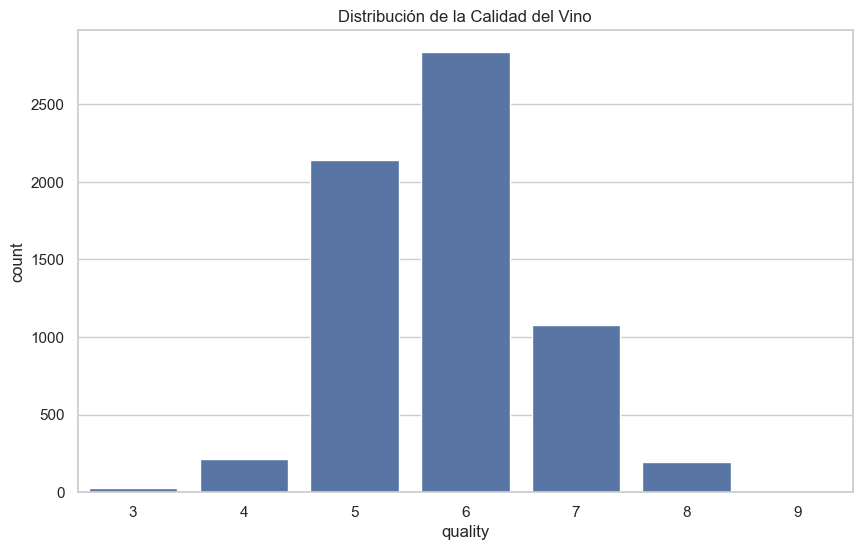

In [5]:
# Distribución de quality

sns.countplot(x=df[target_clasificacion])
plt.title("Distribución de la Calidad del Vino")
plt.show()


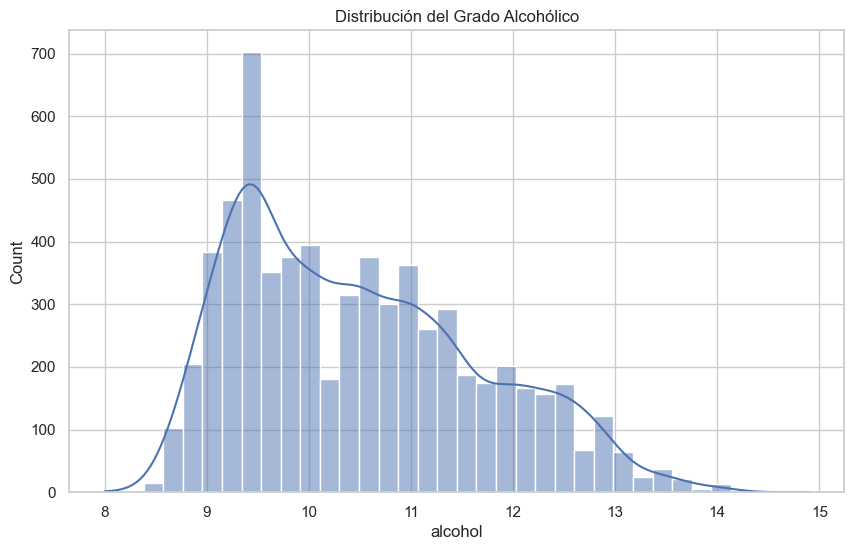

In [6]:
#  Distribución de alcohol

sns.histplot(df[target_regresion], kde=True)
plt.title("Distribución del Grado Alcohólico")
plt.show()


In [7]:
# Correlación con los targets


corr = df.corr(numeric_only=True)

corr[[target_clasificacion, target_regresion]].sort_values(by=target_clasificacion, ascending=False)


,quality,alcohol
quality,1.000000,0.444319
alcohol,0.444319,1.000000
citric acid,0.085532,-0.010493
free sulfur dioxide,0.055463,-0.179838
sulphates,0.038485,-0.003029
pH,0.019506,0.121248
residual sugar,-0.036980,-0.359415
total sulfur dioxide,-0.041385,-0.265740
fixed acidity,-0.076743,-0.095452
chlorides,-0.200666,-0.256916


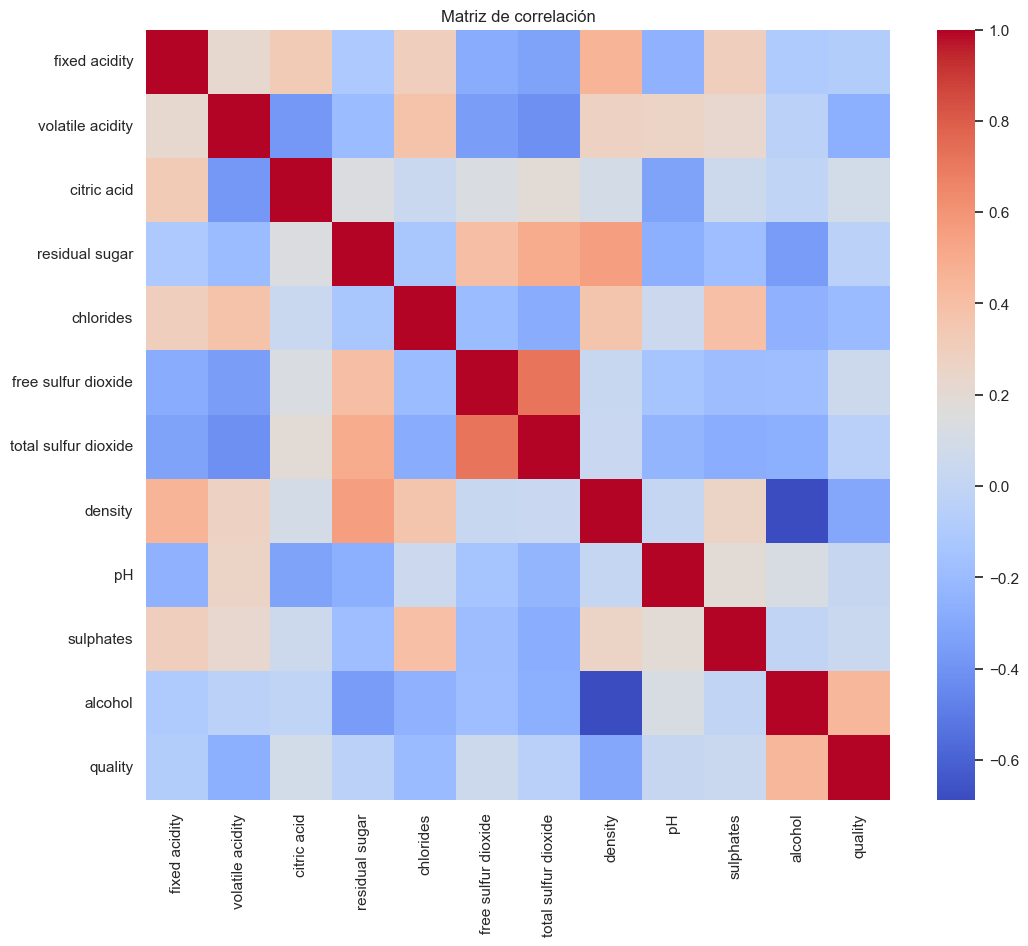

In [8]:
# Heatmap de correlación

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()


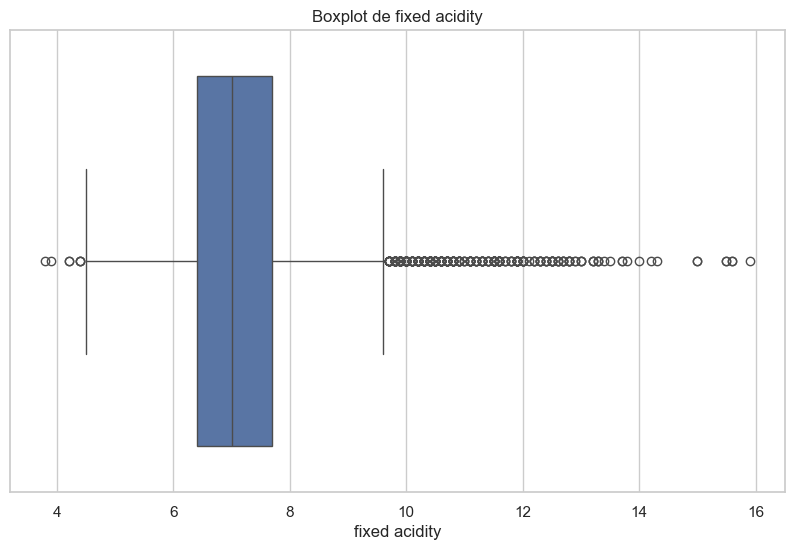

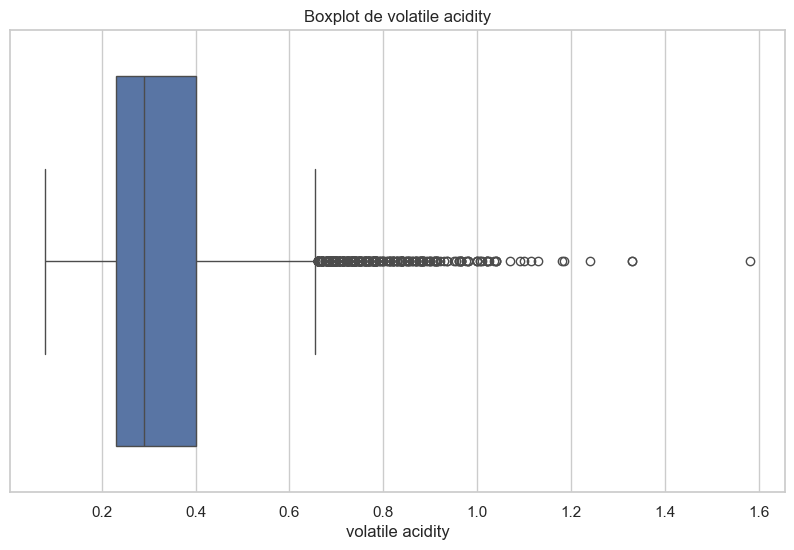

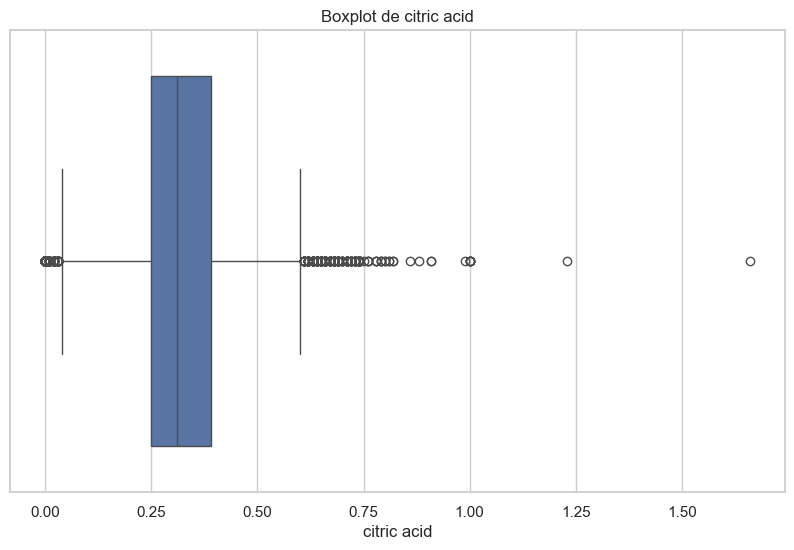

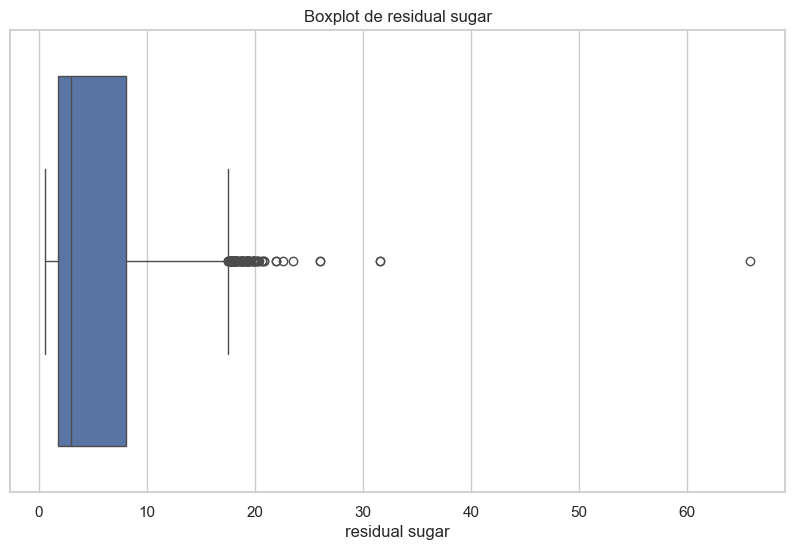

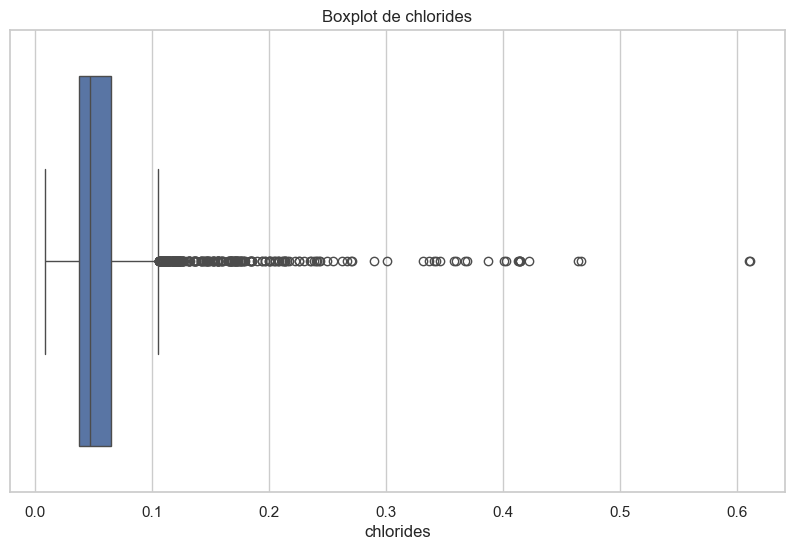

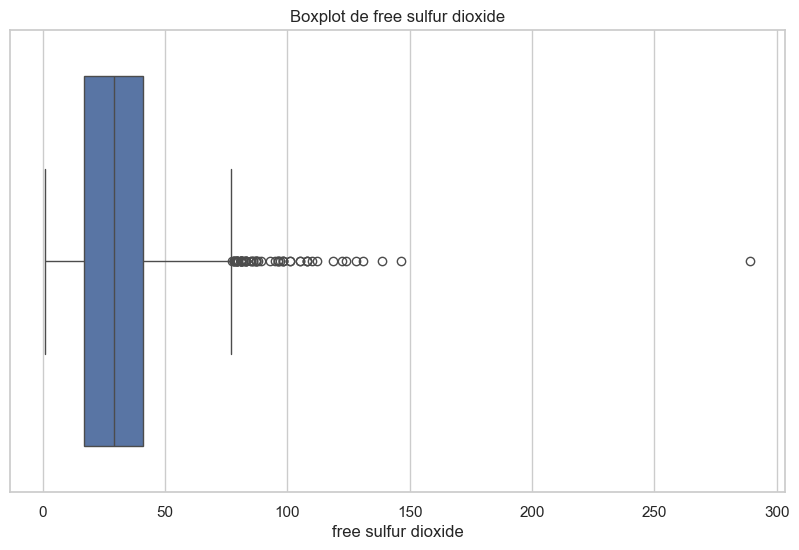

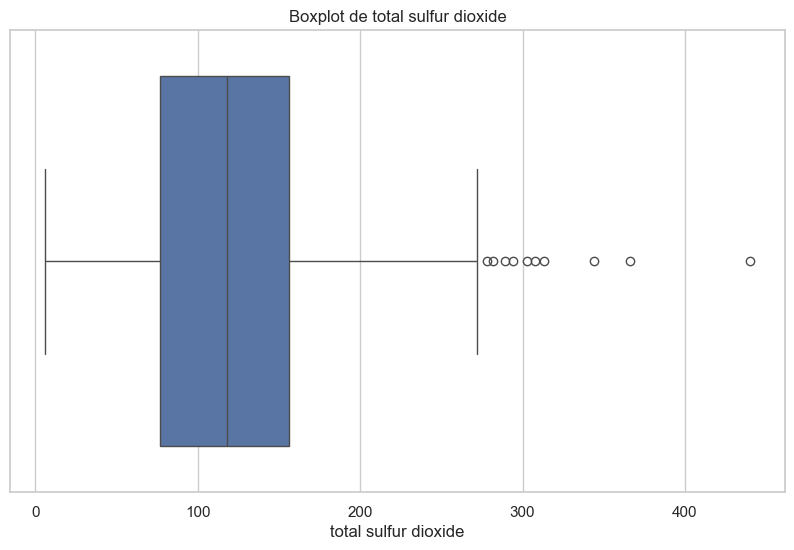

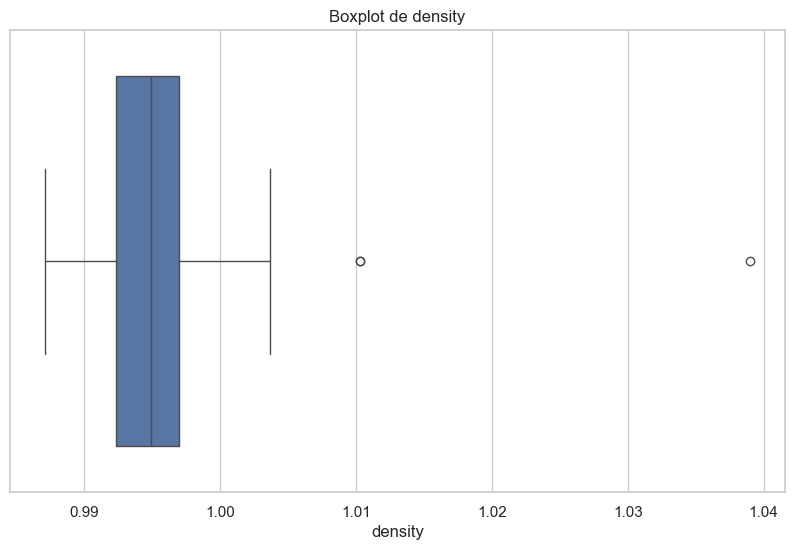

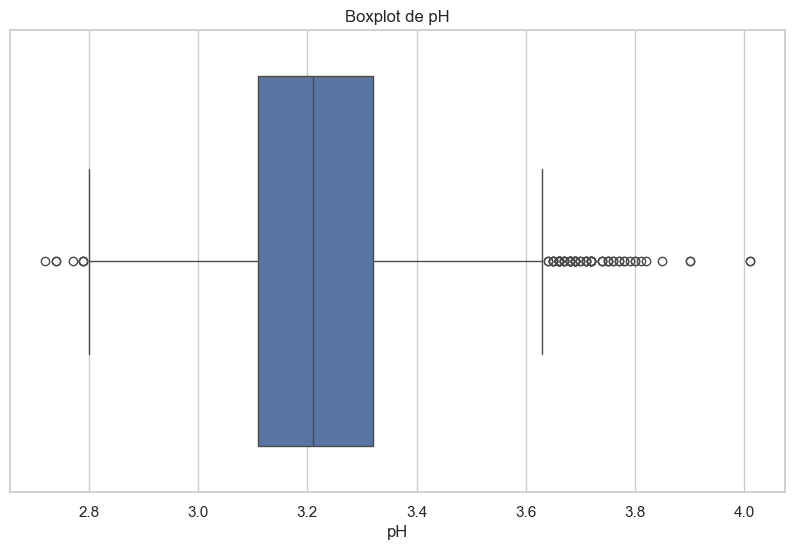

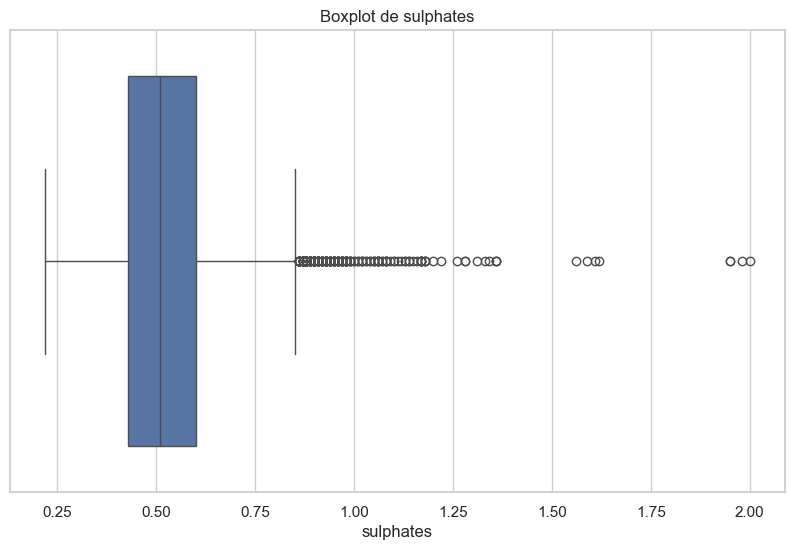

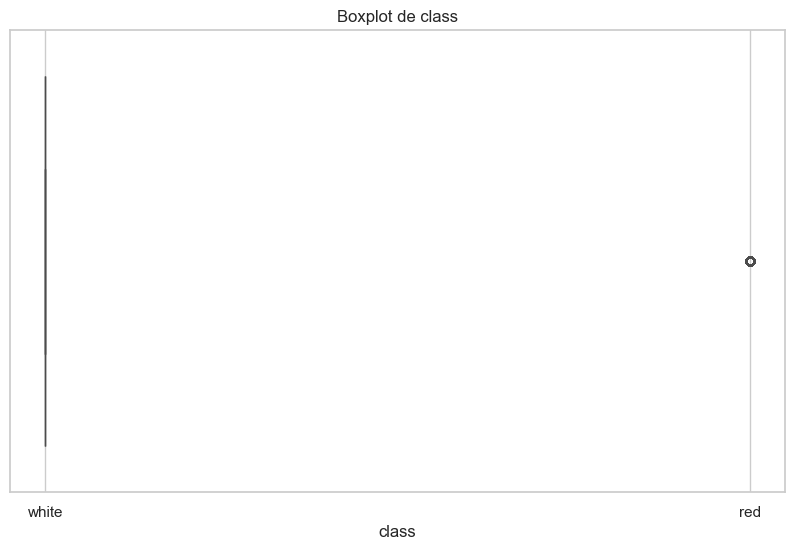

In [9]:
# Detección visual de outliers

for col in features:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()


### EDA inicial

- Existen múltiples variables con outliers claros (residual sugar, chlorides, sulfur dioxide, sulphates).
- Las escalas entre variables son muy distintas → será necesario escalado.
- La variable `quality` está desbalanceada → problema complejo de clasificación.
- La variable `alcohol` presenta buena distribución → problema favorable para regresión.


In [10]:
# CELDA 12: Encoding de la variable class

df["class"] = df["class"].map({"white": 0, "red": 1})

df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,0
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,0
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,0
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,0
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,1


In [11]:
# Separación de variables

X = df[features + ["class"]]

y_clas = df[target_clasificacion]
y_reg = df[target_regresion]

X.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,class,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,0,0
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,0,0
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,0,0
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,0,0
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,1,1


In [12]:
#  Escalado

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,class,class
0,1.153846,-0.470588,-0.357143,0.992063,-0.481481,1.833333,0.303797,-0.083871,-0.761905,-0.823529,0.0,0.0
1,1.000000,-0.764706,0.428571,0.777778,-0.814815,0.375000,-0.139241,-0.393548,-1.333333,-0.823529,0.0,0.0
2,-0.153846,-0.647059,0.500000,-0.253968,-0.333333,0.250000,-0.088608,-0.664516,0.523810,0.470588,0.0,0.0
3,-0.692308,-0.176471,-0.428571,-0.015873,0.000000,10.833333,4.075949,-0.376344,1.095238,0.764706,0.0,0.0
4,0.384615,2.000000,-0.285714,-0.158730,1.333333,-0.500000,-0.341772,0.273118,0.238095,0.411765,1.0,1.0


El escalado es necesario debido a la gran diferencia de magnitudes entre las variables del dataset. Sin este proceso, los modelos darían mayor importancia a aquellas variables con valores numéricos más altos, independientemente de su relevancia real. Se utiliza RobustScaler en lugar de un escalado estándar porque el dataset presenta múltiples outliers, y este método, basado en la mediana y el rango intercuartílico, es menos sensible a valores extremos.

In [13]:
# Comparación antes vs después del escalado

comparacion = pd.DataFrame({
    "Variable": X.columns,
    "Min Antes": X.min().values,
    "Max Antes": X.max().values,
    "Min Después": X_scaled.min().values,
    "Max Después": X_scaled.max().values
})

comparacion


,Variable,Min Antes,Max Antes,Min Después,Max Después
0,fixed acidity,3.80000,15.90000,-2.461538,6.846154
1,volatile acidity,0.08000,1.58000,-1.235294,7.588235
2,citric acid,0.00000,1.66000,-2.214286,9.642857
3,residual sugar,0.60000,65.80000,-0.380952,9.968254
4,chlorides,0.00900,0.61100,-1.407407,20.888889
5,free sulfur dioxide,1.00000,289.00000,-1.166667,10.833333
6,total sulfur dioxide,6.00000,440.00000,-1.417722,4.075949
7,density,0.98711,1.03898,-1.673118,9.481720
8,pH,2.72000,4.01000,-2.333333,3.809524
9,sulphates,0.22000,2.00000,-1.705882,8.764706


### Assessment final previo al modelado

**Clasificación (quality):**
- Dataset desbalanceado.
- Baja varianza en el target.
- Métrica objetivo: Recall Macro.
- Necesario tratamiento especial para clases minoritarias.

**Regresión (alcohol):**
- Buena distribución del target.
- Variables altamente correlacionadas.
- Métrica objetivo: MAPE.
- Problema favorable para modelos de regresión.


### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

In [14]:
# Separación Train/Test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_clas, 
    test_size=0.2, 
    random_state=42,
    stratify=y_clas
)


In [19]:
# CELDA 19: Configuración de validacion cruzada
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


In [20]:
# CELDA 20: Baseline KNN correcto
for k in [3, 7]:
    
    print(f"\nEvaluando KNN con k = {k}")
    
    knn_clf = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    
    scores = cross_val_score(
        knn_clf,
        X_train,
        y_train,
        cv=3,
        scoring='recall_macro',
        n_jobs=-1
    )
    
    print("Recall macro en cada fold:", scores)
    print("Recall macro medio:", scores.mean())



Evaluando KNN con k = 3
Recall macro en cada fold: [0.2823493  0.27977562 0.26537991]
Recall macro medio: 0.27583494336387565

Evaluando KNN con k = 7
Recall macro en cada fold: [0.23603451 0.2595868  0.23936196]
Recall macro medio: 0.24499442155291695


In [21]:
# Logistic Regression

logreg = LogisticRegression(max_iter=5000, class_weight='balanced')

scores = cross_val_score(logreg, X_train, y_train, cv=cv, scoring='recall_macro')
print(f"Logistic Regression - Recall Macro medio: {scores.mean():.4f}")


Logistic Regression - Recall Macro medio: 0.3956


In [22]:
# =========================================
# CELDA 22: Random Forest base
# =========================================

rf = RandomForestClassifier(random_state=42, class_weight='balanced')

scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='recall_macro')
print(f"Random Forest (base) - Recall Macro medio: {scores.mean():.4f}")


Random Forest (base) - Recall Macro medio: 0.3273


In [23]:
# Optimización de hiperparámetros (GridSearch)
# GridSearch Random Forest

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid,
    cv=cv,
    scoring='recall_macro',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor recall_macro:", grid.best_score_)


Mejores parámetros: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Mejor recall_macro: 0.3503509467069457


In [25]:
# Modelo final

best_model = grid.best_estimator_

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)


In [26]:
# Evaluación en test

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.27      0.28      0.28        43
           5       0.62      0.72      0.67       428
           6       0.66      0.47      0.55       567
           7       0.45      0.64      0.53       216
           8       0.37      0.38      0.38        39
           9       0.00      0.00      0.00         1

    accuracy                           0.57      1300
   macro avg       0.34      0.36      0.34      1300
weighted avg       0.58      0.57      0.57      1300



C:\Users\kelly\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kelly\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kelly\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

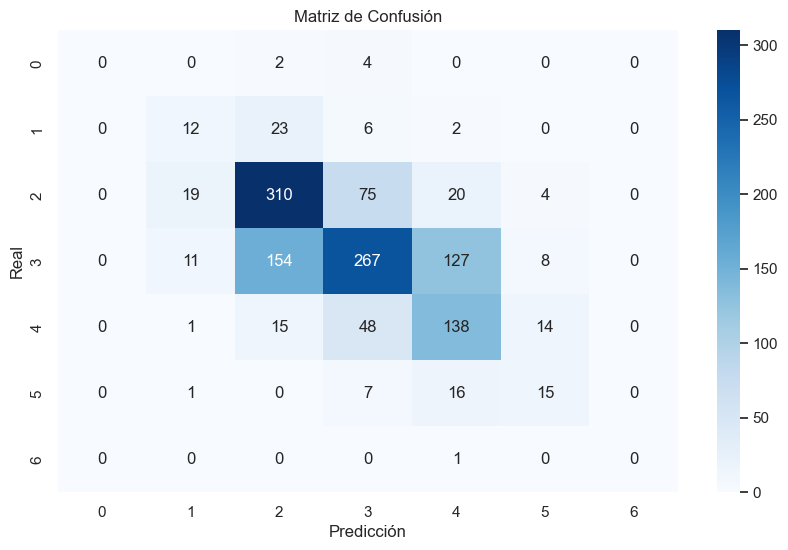

In [27]:
# =========================================
# CELDA 26: Matriz de confusión
# =========================================

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.